In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

df = pd.DataFrame(
    cancer.data,
    columns = cancer.feature_names
)

df['Target'] = cancer.target

In [2]:
X = df.drop('Target',axis=1)
y = df["Target"]

In [3]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model1 = DecisionTreeClassifier()
model1.fit(X_train,y_train)
prediction1 = model1.predict(X_test)
accuracy1 = accuracy_score(y_test,prediction1)
print(f"Model Accuracy: {accuracy1}")

Model Accuracy: 0.9385964912280702


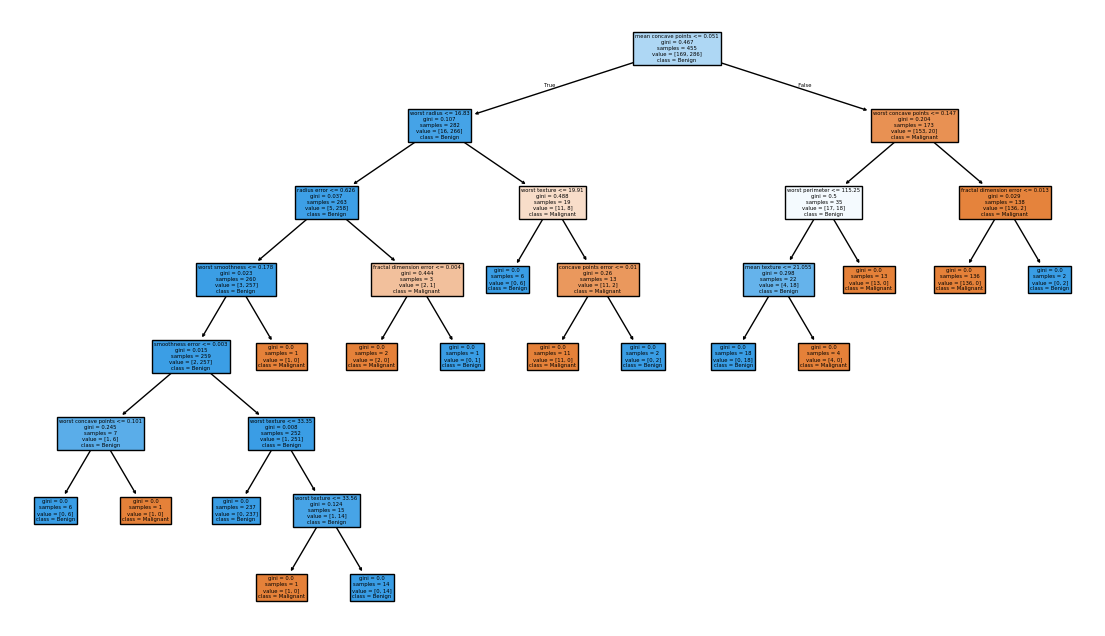

In [5]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))
plot_tree(model1,feature_names=X.columns,class_names=['Malignant','Benign'],filled=True)
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=33)

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model1 = DecisionTreeClassifier()
model1.fit(X_train,y_train)
prediction1 = model1.predict(X_test)
accuracy1 = accuracy_score(y_test,prediction1)
print(f"Model Accuracy: {accuracy1}")

Model Accuracy: 0.8947368421052632


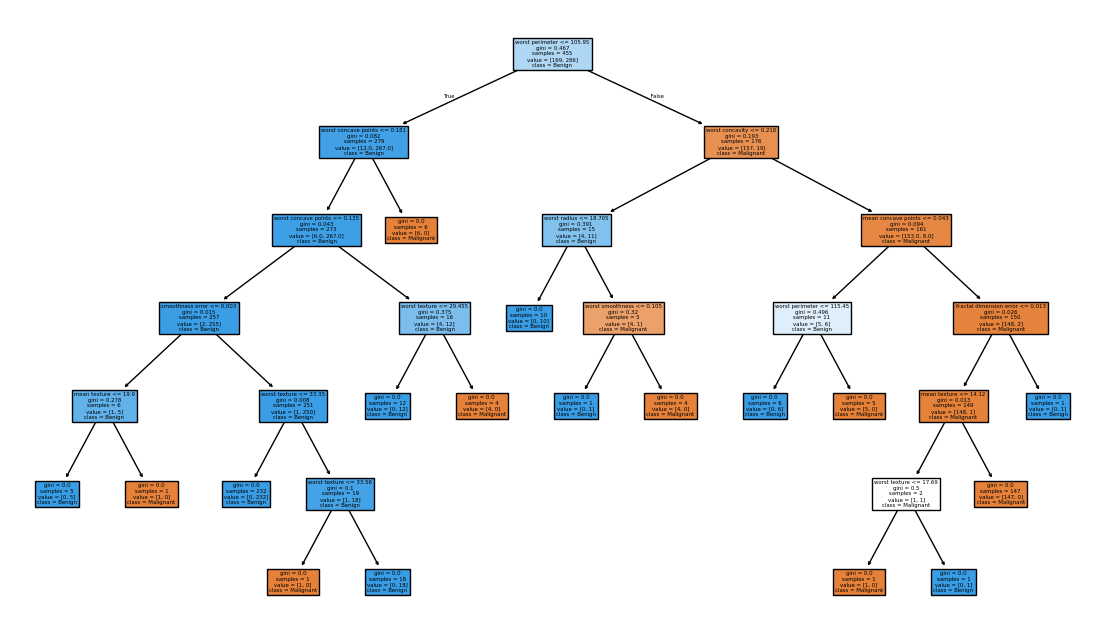

In [8]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))
plot_tree(model1,feature_names=X.columns,class_names=['Malignant','Benign'],filled=True)
plt.show()

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)

rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [10]:
y_pred = rf.predict(X_test)

In [11]:
accuracy2 = accuracy_score(y_test,y_pred)
print(f"Model Accuracy: {accuracy2}")

Model Accuracy: 0.9298245614035088


In [12]:
# 20,40 ,60 ,80,100,120
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

Evaluating RandomForestClassifier for n_estimators from 1 to 111 with a step of 10:

n_estimators = 1: Accuracy = 0.9298, Training Time = 0.0074 seconds
n_estimators = 11: Accuracy = 0.9386, Training Time = 0.0311 seconds
n_estimators = 21: Accuracy = 0.9386, Training Time = 0.0579 seconds
n_estimators = 31: Accuracy = 0.9298, Training Time = 0.0801 seconds
n_estimators = 41: Accuracy = 0.9298, Training Time = 0.1139 seconds
n_estimators = 51: Accuracy = 0.9298, Training Time = 0.1301 seconds
n_estimators = 61: Accuracy = 0.9211, Training Time = 0.1611 seconds
n_estimators = 71: Accuracy = 0.9298, Training Time = 0.1816 seconds
n_estimators = 81: Accuracy = 0.9211, Training Time = 0.3015 seconds
n_estimators = 91: Accuracy = 0.9211, Training Time = 0.3506 seconds
n_estimators = 101: Accuracy = 0.9298, Training Time = 0.3954 seconds
n_estimators = 111: Accuracy = 0.9298, Training Time = 0.4389 seconds


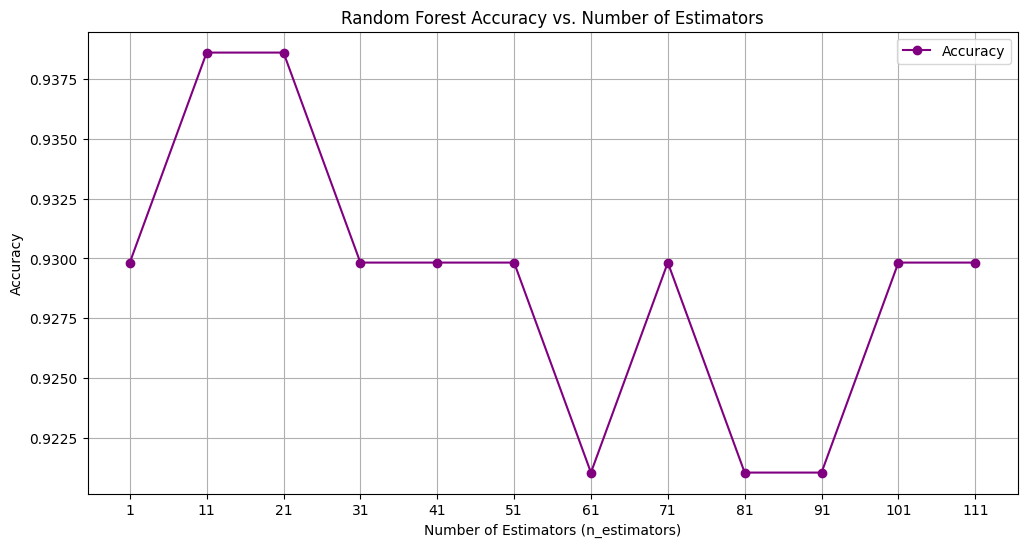

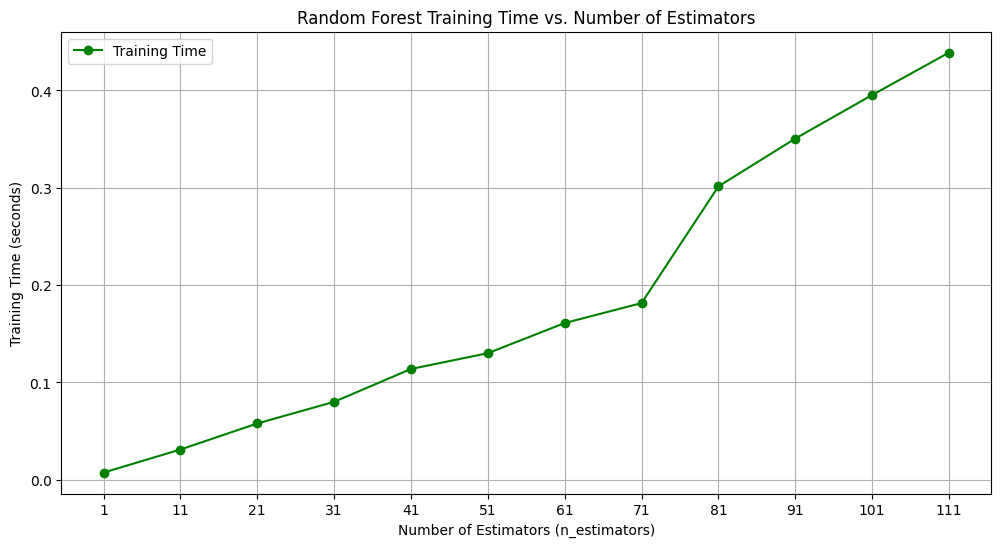


Best n_estimators value: 11 with accuracy: 0.9386


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import time

# Define a range of n_estimators values to test from 1 to 120, stepping by 10
n_estimators_values = list(range(1, 121, 10))
accuracies = []
training_times = []

print(f"Evaluating RandomForestClassifier for n_estimators from {n_estimators_values[0]} to {n_estimators_values[-1]} with a step of 10:\n")

for n_est in n_estimators_values:
    rf_model = RandomForestClassifier(n_estimators=n_est, random_state=42)

    start_time = time.perf_counter()
    rf_model.fit(X_train, y_train)
    end_time = time.perf_counter()

    y_pred_rf = rf_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred_rf)

    accuracies.append(accuracy)
    training_times.append(end_time - start_time)

    print(f"n_estimators = {n_est}: Accuracy = {accuracy:.4f}, Training Time = {end_time - start_time:.4f} seconds")

# Plotting the results
plt.figure(figsize=(12, 6))
plt.plot(n_estimators_values, accuracies, marker='o', linestyle='-', color='purple', label='Accuracy')
plt.title('Random Forest Accuracy vs. Number of Estimators')
plt.xlabel('Number of Estimators (n_estimators)')
plt.ylabel('Accuracy')
plt.xticks(n_estimators_values)
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(n_estimators_values, training_times, marker='o', linestyle='-', color='green', label='Training Time')
plt.title('Random Forest Training Time vs. Number of Estimators')
plt.xlabel('Number of Estimators (n_estimators)')
plt.ylabel('Training Time (seconds)')
plt.xticks(n_estimators_values)
plt.grid(True)
plt.legend()
plt.show()

# Find the best n_estimators and its accuracy
best_n_est_index = accuracies.index(max(accuracies))
best_n_estimators = n_estimators_values[best_n_est_index]
best_accuracy_rf = accuracies[best_n_est_index]

print(f"\nBest n_estimators value: {best_n_estimators} with accuracy: {best_accuracy_rf:.4f}")

In [14]:
importance = pd.DataFrame({
    "Feature":df.columns[:-1],
    "Importance":rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

                 Feature  Importance
23            worst area    0.131472
27  worst concave points    0.118754
7    mean concave points    0.112342
20          worst radius    0.096759
22       worst perimeter    0.090566
2         mean perimeter    0.076730
0            mean radius    0.059365
3              mean area    0.053340
6         mean concavity    0.051559
26       worst concavity    0.035660


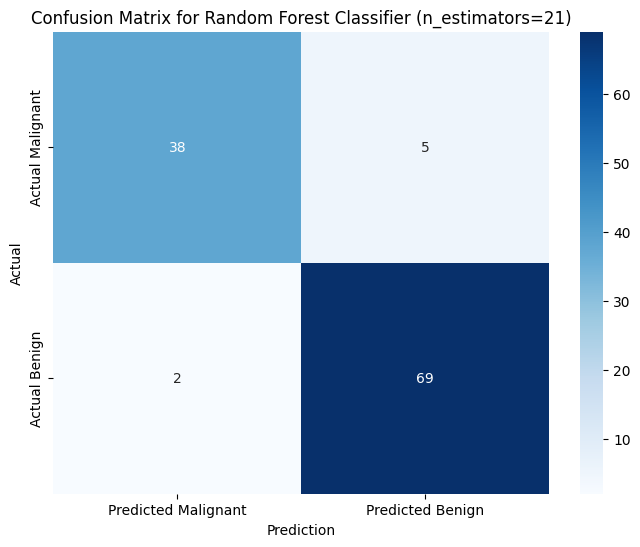

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Re-train the Random Forest model with the best n_estimators (21)
# X_train, X_test, y_train, y_test are already defined from the previous breast cancer classification steps.
final_rf_model = RandomForestClassifier(n_estimators=21, random_state=42)
final_rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_final_rf = final_rf_model.predict(X_test)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_final_rf)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Malignant', 'Predicted Benign'],
            yticklabels=['Actual Malignant', 'Actual Benign'])
plt.title('Confusion Matrix for Random Forest Classifier (n_estimators=21)')
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.show()

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure X and y are correctly defined and X is scaled from the original df
# Reload cancer data to ensure 'df' and 'cancer' are accessible as in previous steps
# (This is a safeguard, as 'df' and 'X' were modified in previous cells)
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
df_original = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df_original['Target'] = cancer.target

X_raw = df_original.drop(columns='Target')
y = df_original['Target']

# Scale the features (consistent with previous Logistic Regression and KNN setup)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Perform train-test split with a consistent random_state
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 455
Testing samples: 114


### 1. Logistic Regression


Logistic Regression Model Evaluation:
Accuracy: 0.9737

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.95      0.96        43
      Benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



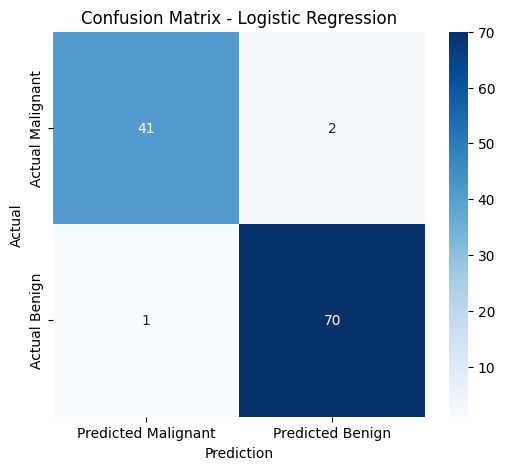

In [17]:
log_reg_model = LogisticRegression(random_state=42, max_iter=200)
log_reg_model.fit(X_train, y_train)
y_pred_log_reg = log_reg_model.predict(X_test)

print("Logistic Regression Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_reg, target_names=['Malignant', 'Benign']))

# Plot Confusion Matrix
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Malignant', 'Predicted Benign'],
            yticklabels=['Actual Malignant', 'Actual Benign'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.show()

### 2. K-Nearest Neighbors (KNN)


KNN Model Evaluation:
Accuracy: 0.9649

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.95      0.95      0.95        43
      Benign       0.97      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



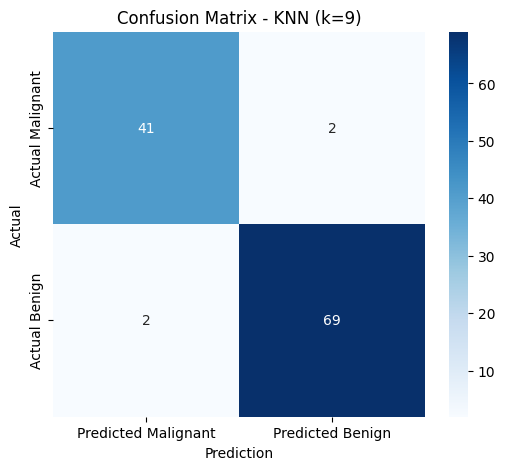

In [18]:
knn_model = KNeighborsClassifier(n_neighbors=9) # Using best k=9 from previous analysis
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

print("KNN Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn, target_names=['Malignant', 'Benign']))

# Plot Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Malignant', 'Predicted Benign'],
            yticklabels=['Actual Malignant', 'Actual Benign'])
plt.title('Confusion Matrix - KNN (k=9)')
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.show()

### 3. Decision Tree Classifier


Decision Tree Model Evaluation:
Accuracy: 0.9474

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.93      0.93      0.93        43
      Benign       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



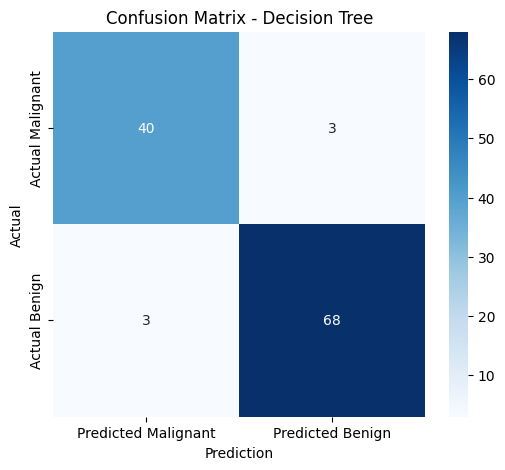

In [19]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=['Malignant', 'Benign']))

# Plot Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Malignant', 'Predicted Benign'],
            yticklabels=['Actual Malignant', 'Actual Benign'])
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.show()

### 4. Random Forest Classifier


Random Forest Model Evaluation:
Accuracy: 0.9649

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.93      0.95        43
      Benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



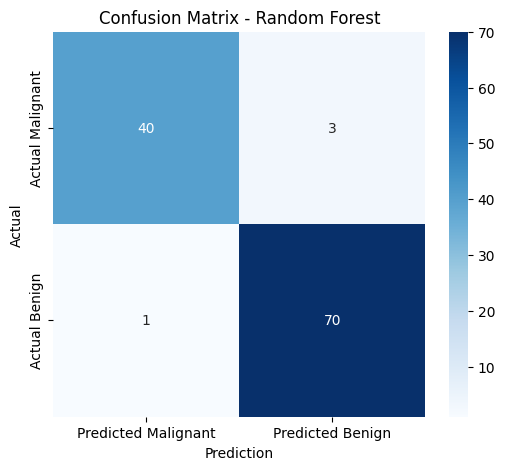

In [20]:
rf_model = RandomForestClassifier(n_estimators=21, random_state=42) # Using best n_estimators=21 from previous analysis
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Malignant', 'Benign']))

# Plot Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Malignant', 'Predicted Benign'],
            yticklabels=['Actual Malignant', 'Actual Benign'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.show()